In [49]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm as tqdm
import joblib as joblib
import importlib as importlib
import scipy as sp
import qutip as qt
from scipy.optimize import minimize

When sent a coherent state, we would like to be able to differentiate what state is measured with a normal photodetector. This detector can either mease 0 photons or >1 photons. We would like to know if we have measured $|\alpha\rangle$ or $|-\alpha\rangle$. If the coherent states are close to each other, they will have some overlap where it becomes very hard to distinguish which signal was measured. To combat this, one can displace the incomming signal by $D(\alpha)$ or $D(-\alpha)$. This way, if one of the signals was sent, it will be displaced to the vacuum coherent $|0\rangle$ state, and the other will be displaced to $|2\alpha \rangle$. Depending on wether the photodetector measures a photon or not, it will become easier to distinguish what signal was sent.

We can visualize the Wigner function of the two coherent states $|\alpha\rangle$ and $|-\alpha\rangle$ in phase space with qutip. (Remember only one signal is sent, here both possibilities are visualized together.)

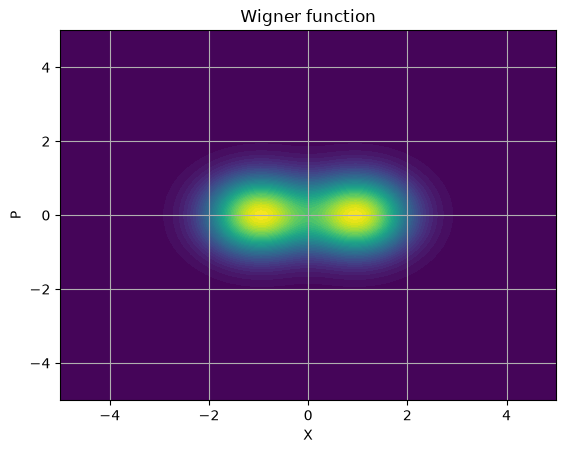

In [50]:
#coherent state from qutip
alpha = 0.7 + 0j
N = 100
coherent_state1 = qt.coherent(N, alpha)
coherent_state2 = qt.coherent(N, -alpha)
#plot in phase space
fig, ax = plt.subplots()
coherent_wigner1 = qt.wigner(coherent_state1, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
coherent_wigner2 = qt.wigner(coherent_state2, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
sum_wigner = coherent_wigner1 + coherent_wigner2
ax.contourf(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100), sum_wigner, 50)
ax.set_xlabel('X')
ax.set_ylabel('P')
ax.set_title('Wigner function')
ax.grid()

After the displacement $D(\alpha)$ on the signal, it will be moved accordingly in phase space.

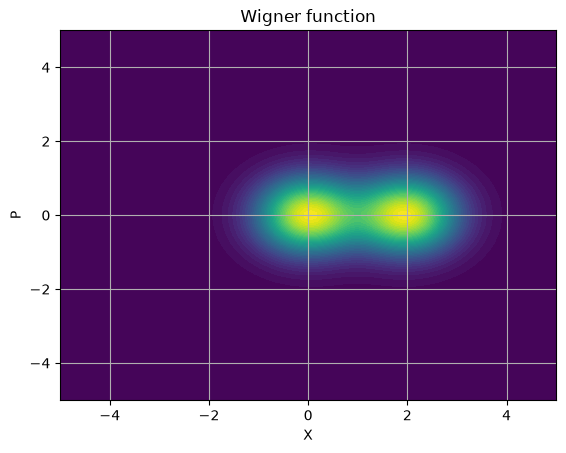

In [51]:
displace_alpha = qt.displace(N, alpha)
coherent_state1_displaced = displace_alpha * coherent_state1
coherent_state2_displaced = displace_alpha * coherent_state2
fig, ax = plt.subplots()
coherent_wigner1 = qt.wigner(coherent_state1_displaced, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
coherent_wigner2 = qt.wigner(coherent_state2_displaced, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
sum_wigner = coherent_wigner1 + coherent_wigner2
ax.contourf(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100), sum_wigner, 50)
ax.set_xlabel('X')
ax.set_ylabel('P')
ax.set_title('Wigner function')
ax.grid()


In [52]:
def extract_alpha(coherent_state):
    a = qt.destroy(N)
    extracted_alpha = (coherent_state.dag() * a * coherent_state)
    return extracted_alpha

def kennedy_receiver(coherent1, coherent2, N):
    #extract alpha from coherent state
    alpha1 = extract_alpha(coherent1)
    alpha2 = extract_alpha(coherent2)
    #displace states by -alpha1
    displaced1 = qt.displace(N, -alpha1) * coherent1
    displaced2 = qt.displace(N, -alpha1) * coherent2
    #vacuum state
    vac_projector = qt.fock_dm(N, 0)
    prob_of_zero1 = qt.expect(vac_projector, displaced1)
    prob_of_zero2 = qt.expect(vac_projector, displaced2)
    prob_of_one1 = 1 - prob_of_zero1
    prob_of_one2 = 1 - prob_of_zero2
    #plot the before displacement and after displacement states in phase space
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 5))
    print(type(alpha1))
    maxR = np.max([np.abs(alpha1.real), np.abs(alpha2.real)])
    maxI = np.max([np.abs(alpha1.imag), np.abs(alpha2.imag)])
    plot_ranges_from_alpha = max(maxR, maxI) *3*np.sqrt(2)
    before_wigner1 = qt.wigner(coherent1, np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100))
    before_wigner2 = qt.wigner(coherent2, np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100))
    after_wigner1 = qt.wigner(displaced1, np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100))
    after_wigner2 = qt.wigner(displaced2, np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100))
    wigner_list = [before_wigner1, before_wigner2, after_wigner1, after_wigner2]
    for ax in [ax1, ax2, ax3, ax4]:
        ax.contourf(np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), wigner_list.pop(0), 50)
        ax.set_xlabel('X')
        ax.set_ylabel('P')
        ax.grid()
    ax1.set_title('Before displacement: State 1')
    ax2.set_title('Before displacement: State 2')
    ax3.set_title('After displacement: State 1')
    ax4.set_title('After displacement: State 2')
    print("After displacement:")
    print(f"If state 1 was sent, the probability of detecting a photon is: {prob_of_one1:.4f}")
    print(f"If state 2 was sent, the probability of detecting a photon is: {prob_of_one2:.4f}")



Here we can see how the displacement affects the signal depending on what coherent state is sent. One is moved to the vacuum state and one to a greater coherent state.

<class 'complex'>
After displacement:
If state 1 was sent, the probability of detecting a photon is: -0.0000
If state 2 was sent, the probability of detecting a photon is: 0.8647


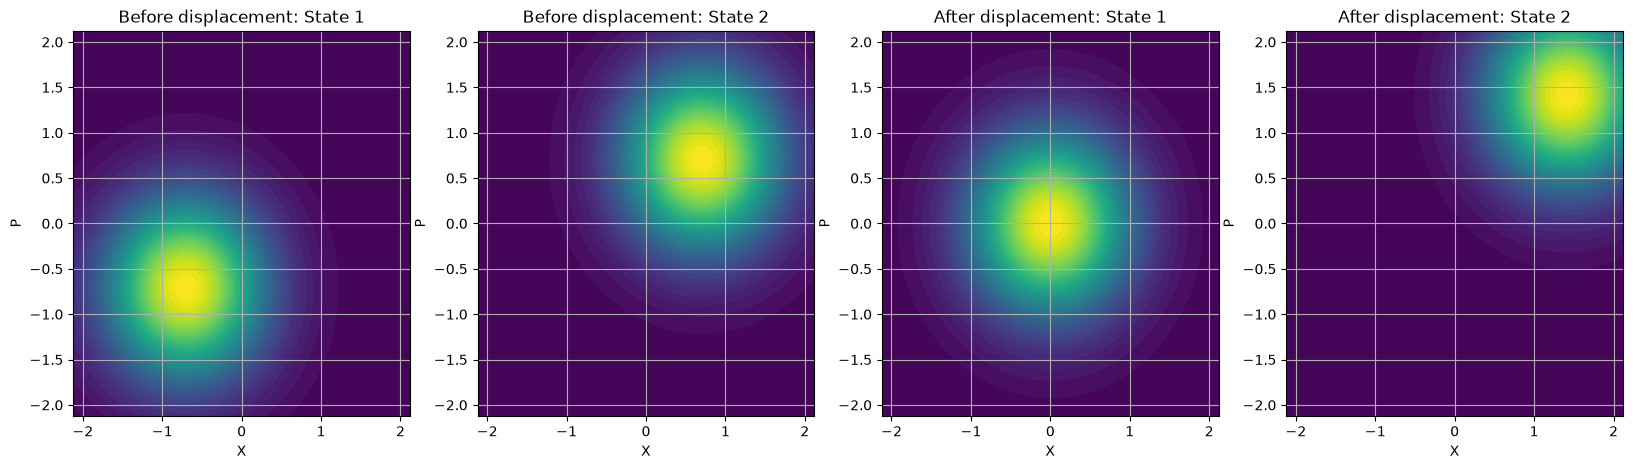

In [53]:
N = 50
alpha1 = -0.5 - 0.5j
alpha2 = 0.5 + 0.5j
coherent1 = qt.coherent(N, alpha1)
coherent2 = qt.coherent(N, alpha2)
kennedy_receiver(coherent1, coherent2, N)

Dolinar explaination

Instead of simulating the coherent states with qutip, we can calculate probabilities directly of coherent states without the package. This way we get around qutip creating big matricies and calculating on them.

Applying a displacement on a coherent state is done like so:
$$
D(-\beta)|\alpha\rangle = |\alpha -\beta\rangle = |\gamma\rangle
$$
The probability of measuring the vacuum state from this state is given as:
$$
P_0 = |\langle 0|\gamma\rangle|^2 = e^{-|\gamma|^2}
$$
If the sent state was $|\alpha\rangle$ then $\gamma=0$ and thus $P_0 = 1$. If the sent state was $|\alpha\rangle$, then $P_0 = e^{-4|\alpha|^2}$, which is not zero. The following functions splits the signal into a certain amount, then displaces the signal acoordingly.

In [54]:

def dolinar_receiver_math(alpha_signal, num_splits, dark_count_rate=0.0):
    sliced_alpha = alpha_signal / np.sqrt(num_splits)
    guess_sliced_alpha = np.abs(alpha_signal) / np.sqrt(num_splits)
    click_count = 0
    for step in range(num_splits):
        gamma = sliced_alpha - guess_sliced_alpha
        prob_0 = np.exp(-np.abs(gamma)**2)
        prob_0_actual = prob_0 * (1.0 - dark_count_rate)
        prob_click = 1.0 - prob_0_actual
        detec_click = np.random.rand() < prob_click
        if detec_click:
            click_count += 1
            guess_sliced_alpha = -guess_sliced_alpha
    final = "+alpha" if guess_sliced_alpha > 0 else "-alpha"
    return final, click_count


In [55]:
alpha = 2
N = 50
state = qt.coherent(N, alpha)
num_splits = 1
dark_count_rate = 0.05
dolinar_result, clicks = dolinar_receiver_math(alpha, num_splits, dark_count_rate)
print(f"Dolinar receiver result: {dolinar_result}, Clicks detected: {clicks}")

Dolinar receiver result: +alpha, Clicks detected: 0


In [56]:
def evaluate_split_success(num_splits, alpha, dark_count_rate, N, runs_pr_split):
    correct_guesses = 0
    for _ in range(runs_pr_split):
        true_sign = np.random.choice([1, -1])
        true_signal = true_sign * alpha
        expected_result = "+alpha" if true_signal > 0 else "-alpha"
        dolinar_result, _ = dolinar_receiver_math(true_signal, num_splits, dark_count_rate)
        if dolinar_result == expected_result:
            correct_guesses += 1
    return correct_guesses / runs_pr_split

In [57]:
splitrange = range(1, 31)
alpha = 0.3
dark_count_rate = 0.0
N = 100
runs_pr_split = 10000
success_rates = joblib.Parallel(n_jobs=-1, prefer="threads")(
    joblib.delayed(evaluate_split_success)(
        num_splits, alpha, dark_count_rate, N, runs_pr_split
    )
    for num_splits in tqdm.tqdm(splitrange, desc="Evaluating split counts")
)

Evaluating split counts: 100%|██████████| 30/30 [00:00<00:00, 1398.29it/s]


Here we see that the success rate is really stinky still, and not increasing with the amount of splits.

Text(0, 0.5, 'Success Rate')

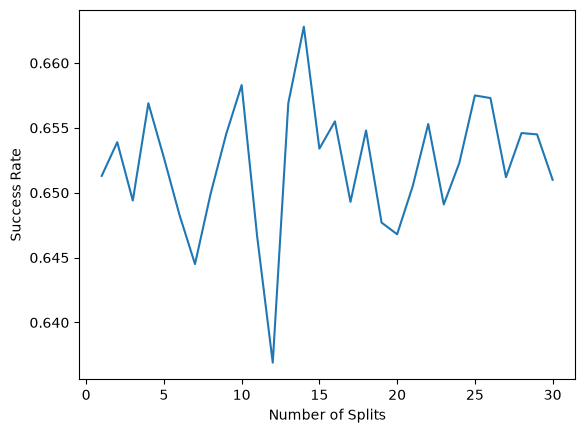

In [58]:
fig, ax = plt.subplots()
ax.plot(splitrange, success_rates)
ax.set_xlabel("Number of Splits")
ax.set_ylabel("Success Rate")

It turns out that the best displacement to give from step to step is not displacing perfectly to vacuum state. Ideally it is actually best to displace a little further than the vaccum state. This way we increase alpha for the non-vacuum state, thus decreasing the probability of measureing zero photons if that state was sent. If the extra displacement is too big, then the probability of measureing photons in the zero state increases as well. There is therefore an optimal small extra displacement $\beta$ that will result in the receiver guessing the sent state correctly more often (decreasing the error probability). The following codeblocks plot simulation for finding the best $\beta$ values.

In [59]:
def kennedy_with_extra_displacement(true_sig, alpha, beta, dark_count_rate=0):
    displacement = - (alpha + beta)
    gamma = true_sig + displacement
    prob_0 = np.exp(-np.abs(gamma)**2)
    prob_0_actual = prob_0 * (1.0 - dark_count_rate)
    prob_click = 1.0 - prob_0_actual
    detector_clicked = np.random.rand() < prob_click
    if not detector_clicked:
        return "+alpha"
    elif detector_clicked:
        return "-alpha"


alpha = 0.2
beta = np.linspace(-1, 1, 100)
rounds_pr_beta = 1000
success_rates_beta = []
for b in tqdm.tqdm(beta, desc="Evaluating beta values"):
    correct_guesses = 0
    for _ in range(rounds_pr_beta):
        true_sign = np.random.choice([1, -1])
        true_signal = true_sign * alpha
        expected_result = "+alpha" if true_signal > 0 else "-alpha"
        kennedy_result = kennedy_with_extra_displacement(true_signal, alpha, b)
        if kennedy_result == expected_result:
            correct_guesses += 1
    success_rate = correct_guesses / rounds_pr_beta
    success_rates_beta.append(success_rate)

Evaluating beta values: 100%|██████████| 100/100 [00:53<00:00,  1.86it/s]


Text(0.5, 1.0, 'Success Rate vs Beta for alpha=0.2')

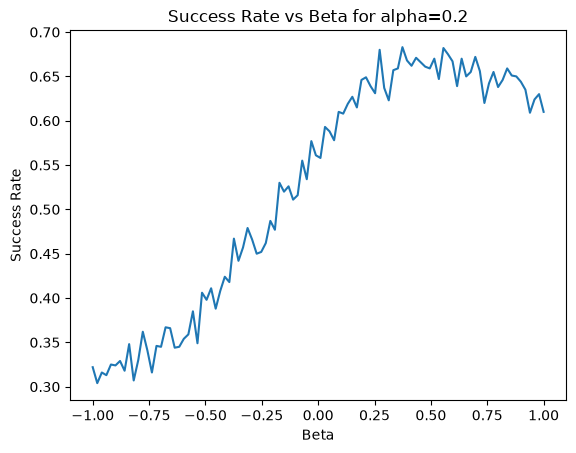

In [60]:
fig, ax = plt.subplots()
ax.plot(beta, success_rates_beta)
ax.set_xlabel("Beta")
ax.set_ylabel("Success Rate")
ax.set_title(f"Success Rate vs Beta for alpha={alpha}")

Scanning beta_0...


beta_0: 100%|██████████| 40/40 [00:01<00:00, 27.49it/s]


Scanning beta_1...


beta_1: 100%|██████████| 40/40 [00:09<00:00,  4.12it/s]


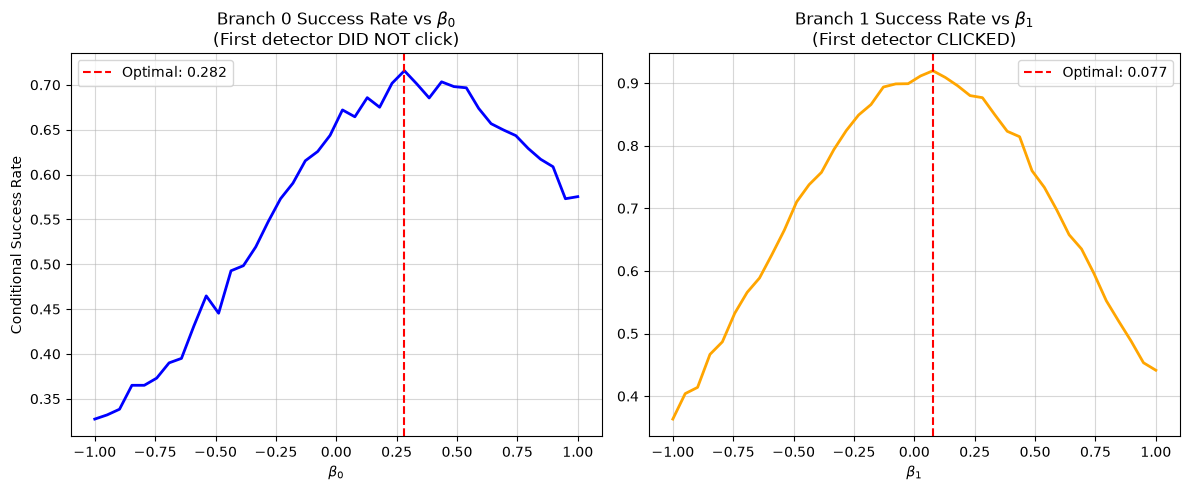

In [ ]:
def evaluate_beta_0(b0, alpha, beta_init, target_valid_runs):
    """Evaluates ONLY the branch where the first detector DOES NOT click."""
    valid_runs = 0
    correct_guesses = 0
    
    while valid_runs < target_valid_runs:
        # 1. Random true signal
        true_sign = np.random.choice([1, -1])
        slice_alpha = (true_sign * alpha) / np.sqrt(2)
        ref_alpha = alpha / np.sqrt(2)
        
        # 2. Stage 1
        disp1 = -(ref_alpha + beta_init)
        gamma1 = slice_alpha + disp1
        prob_0_1 = np.exp(-np.abs(gamma1)**2)
        click1 = np.random.rand() > prob_0_1
        
        # 3. Filter for Branch 0
        if not click1:
            valid_runs += 1
            # Apply beta_0
            disp2 = -(ref_alpha + b0)
            gamma2 = slice_alpha + disp2
            prob_0_2 = np.exp(-np.abs(gamma2)**2)
            click2 = np.random.rand() > prob_0_2
            
            # If Branch 0 clicks, we flip guess from +1 to -1
            final_guess = -1 if click2 else 1
            if final_guess == true_sign:
                correct_guesses += 1
                
    return b0, correct_guesses / target_valid_runs


def evaluate_beta_1(b1, alpha, beta_init, target_valid_runs):
    """Evaluates ONLY the branch where the first detector CLICKS."""
    valid_runs = 0
    correct_guesses = 0
    
    while valid_runs < target_valid_runs:
        # 1. Random true signal
        true_sign = np.random.choice([1, -1])
        slice_alpha = (true_sign * alpha) / np.sqrt(2)
        ref_alpha = alpha / np.sqrt(2)
        
        # 2. Stage 1
        disp1 = -(ref_alpha + beta_init)
        gamma1 = slice_alpha + disp1
        prob_0_1 = np.exp(-np.abs(gamma1)**2)
        click1 = np.random.rand() > prob_0_1
        
        # 3. Filter for Branch 1
        if click1:
            valid_runs += 1
            # Apply beta_1 (Note: displacement is positive here!)
            disp2 = +(ref_alpha + b1)
            gamma2 = slice_alpha + disp2
            prob_0_2 = np.exp(-np.abs(gamma2)**2)
            click2 = np.random.rand() > prob_0_2
            
            # If Branch 1 clicks, we flip guess from -1 to +1
            final_guess = 1 if click2 else -1
            if final_guess == true_sign:
                correct_guesses += 1
                
    return b1, correct_guesses / target_valid_runs

alpha = 0.3
beta_init = 0.2
beta_array = np.linspace(-1, 1, 40)
rounds_pr_beta = 3000  # High number for smooth curves!

print("Scanning beta_0...")
results_b0 = joblib.Parallel(n_jobs=-1, prefer="threads")(
    joblib.delayed(evaluate_beta_0)(b, alpha, beta_init, rounds_pr_beta)
    for b in tqdm.tqdm(beta_array, desc="beta_0")
)

print("Scanning beta_1...")
results_b1 = joblib.Parallel(n_jobs=-1, prefer="threads")(
    joblib.delayed(evaluate_beta_1)(b, alpha, beta_init, rounds_pr_beta)
    for b in tqdm.tqdm(beta_array, desc="beta_1")
)

# Unpack results
b0_vals, b0_success = zip(*results_b0)
b1_vals, b1_success = zip(*results_b1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot Beta 0
ax[0].plot(b0_vals, b0_success, color='blue', lw=2)
opt_b0 = b0_vals[np.argmax(b0_success)]
ax[0].axvline(opt_b0, color='red', linestyle='--', label=f'Optimal: {opt_b0:.3f}')
ax[0].set_title("Branch 0 Success Rate vs $\\beta_0$\n(First detector DID NOT click)")
ax[0].set_xlabel("$\\beta_0$")
ax[0].set_ylabel("Conditional Success Rate")
ax[0].legend()
ax[0].grid(True, alpha=0.5)

# Plot Beta 1
ax[1].plot(b1_vals, b1_success, color='orange', lw=2)
opt_b1 = b1_vals[np.argmax(b1_success)]
ax[1].axvline(opt_b1, color='red', linestyle='--', label=f'Optimal: {opt_b1:.3f}')
ax[1].set_title("Branch 1 Success Rate vs $\\beta_1$\n(First detector CLICKED)")
ax[1].set_xlabel("$\\beta_1$")
ax[1].legend()
ax[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

In [62]:
from scipy.optimize import root_scalar
beta_init = 0.2
alpha = 0.3/np.sqrt(2)
def beta0_func(beta0):
    return np.log((2*alpha+beta0)/beta0) - 4*alpha*beta0 - 8*alpha**2 - 4*alpha*beta_init
def beta1_func(beta1):
    return np.log((2*alpha+beta1)/beta1) - 4*alpha**2 - 4*alpha*beta1 - np.log((1-np.exp(-(2*alpha+beta_init)**2))/(1-np.exp(-beta_init**2)))
root0 = root_scalar(beta0_func, bracket=[1e-5, 1])
root1 = root_scalar(beta1_func, bracket=[1e-5, 1])
print(root0.root, root1.root)

0.33669551327669733 0.045888127832284305


In [63]:
def dolinar_receiver_dynamic_beta(true_signal, beta_init, num_splits, dark_count_rate=0.0):
    alpha_magnitude = np.abs(true_signal)
    alpha_s = alpha_magnitude / np.sqrt(num_splits)
    guess_sign = np.random.choice([1, -1])  # Random initial guess
    current_beta = beta_init
    click_count = 0
    for step in range(num_splits):
        guess_displacement = guess_sign * (alpha_s + current_beta)
        sliced_true = true_signal / np.sqrt(num_splits)
        gamma = sliced_true - guess_displacement
        prob_0 = np.exp(-np.abs(gamma)**2)
        prob_0_actual = prob_0 * (1.0 - dark_count_rate)
        prob_click = 1.0 - prob_0_actual
        detec_click = np.random.rand() < prob_click
        if detec_click:
            #gættet forkert
            click_count += 1
            guess_sign *= -1
            if current_beta == 0.0:
                current_beta = 0.0 # 100% certainty, no extra displacement needed
                print("Warning: current_beta is 0.0, no extra displacement needed")
            else:
                def beta1_func(b):
                    left = np.log((2*alpha_s+b)/b) - 4*alpha_s**2 - 4*alpha_s*b
                    right = np.log((1-np.exp(-(2*alpha_s+current_beta)**2))/(1-np.exp(-current_beta**2)))
                    return left - right
                try:
                    root1 = root_scalar(beta1_func, bracket=[1e-6, 2.0])
                    current_beta = root1.root
                except ValueError:
                    current_beta = 0.0 # Safety fallback
                    print("Warning: No root found for beta1_func, setting current_beta to 0.0")
        else:
            #gættet rigtigt
            def beta0_func(b):
                return np.log((2*alpha_s+b)/b) - 4*alpha_s*b - 8*alpha_s**2 - 4*alpha_s*current_beta
            try:
                root0 = root_scalar(beta0_func, bracket=[1e-6, 2.0])
                current_beta = root0.root
            except ValueError:
                current_beta = 0.0 # Safety fallback
                print("Warning: No root found for beta0_func, setting current_beta to 0.0")
    final_decision = "+alpha" if guess_sign > 0 else "-alpha"
    return final_decision, click_count
def evaluate_split_success(num_splits, alpha, dark_count_rate, N, runs_pr_split):
    correct_guesses = 0
    for _ in range(runs_pr_split):
        true_sign = np.random.choice([1, -1])
        true_signal = true_sign * alpha
        expected_result = "+alpha" if true_signal > 0 else "-alpha"
        dolinar_result, _ = dolinar_receiver_dynamic_beta(true_signal, beta_init, num_splits, dark_count_rate)
        if dolinar_result == expected_result:
            correct_guesses += 1
    return correct_guesses / runs_pr_split

Evaluating split counts: 100%|██████████| 20/20 [00:00<00:00, 686.98it/s]


Text(0, 0.5, 'Success Rate')

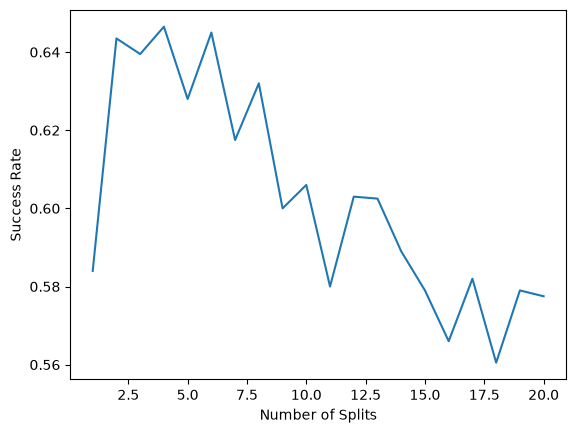

In [64]:
splitrange = range(1, 21)
alpha = 0.2
beta_init = 0.01
dark_count_rate = 0.0
N = 50
runs_pr_split = 2000
success_rates = joblib.Parallel(n_jobs=-1, prefer="threads")(
    joblib.delayed(evaluate_split_success)(
        num_splits, alpha, dark_count_rate, N, runs_pr_split
    )
    for num_splits in tqdm.tqdm(splitrange, desc="Evaluating split counts")
)
fig, ax = plt.subplots()
ax.plot(splitrange, success_rates)
ax.set_xlabel("Number of Splits")
ax.set_ylabel("Success Rate")

Running Bayesian Adaptive Dolinar Receiver...


Evaluating splits: 100%|██████████| 14/14 [00:00<00:00, 9966.10it/s]


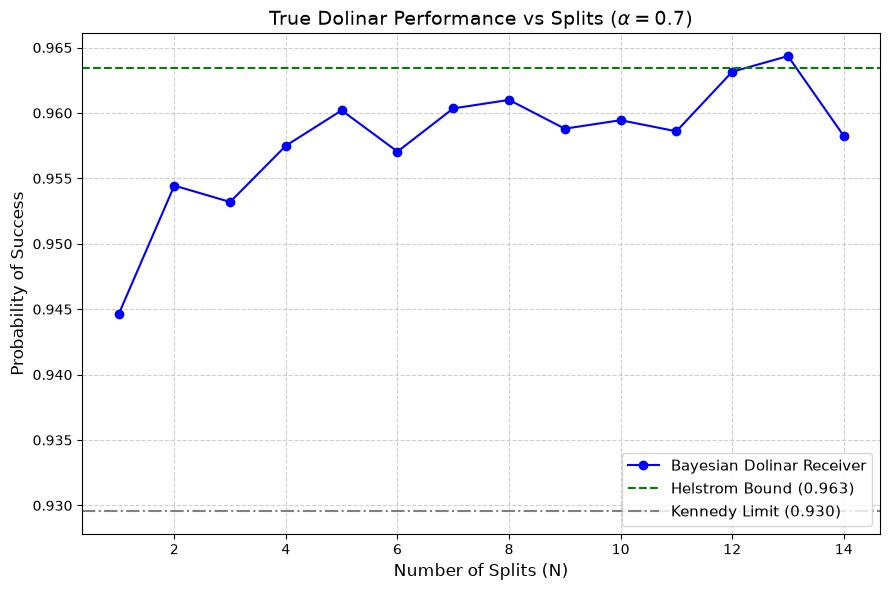

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
import joblib
import tqdm

def bayesian_dolinar_receiver(true_signal, alpha_magnitude, num_splits, dark_count_rate=0.0):
    alpha_s = alpha_magnitude / np.sqrt(num_splits)
    # 1. THE MISSING PIECE: Cumulative Bayesian Memory
    # We start exactly 50/50 uncertain.
    P_plus = 0.5 
    for _ in range(num_splits):
        # 2. Determine our best guess based on current confidence
        if P_plus >= 0.5:
            guess_sign = 1
            P_guess = P_plus
        else:
            guess_sign = -1
            P_guess = 1.0 - P_plus
        # 3. Dynamically calculate the optimal beta!
        # As P_guess gets closer to 1.0 (100% certain), beta shrinks to 0.
        if P_guess > 0.99999:
            beta = 0.0
        else:
            rhs = np.log(P_guess / (1.0 - P_guess))
            def func(b):
                return np.log((2*alpha_s + b)/b) - 4*alpha_s**2 - 4*alpha_s*b - rhs
            try:
                res = root_scalar(func, bracket=[1e-12, 4.0])
                beta = res.root
            except ValueError:
                beta = 0.0
                print("Warning: No root found for beta, setting beta to 0.0")
        # 4. Apply displacement
        disp = -guess_sign * (alpha_s + beta)
        # 5. Physical Measurement
        gamma_actual = true_signal/np.sqrt(num_splits) + disp
        p0_actual = np.exp(-np.abs(gamma_actual)**2) * (1.0 - dark_count_rate)
        clicked = np.random.rand() > p0_actual
        # 6. BAYESIAN UPDATE
        # Calculate the theoretical chance of 0 photons for BOTH possible realities
        gamma_if_plus = alpha_s + disp
        gamma_if_minus = -alpha_s + disp
        
        p0_if_plus = np.exp(-np.abs(gamma_if_plus)**2) * (1.0 - dark_count_rate)
        p0_if_minus = np.exp(-np.abs(gamma_if_minus)**2) * (1.0 - dark_count_rate)
        
        # Update P_plus using Bayes' Theorem
        if not clicked:
            num = P_plus * p0_if_plus
            den = num + (1.0 - P_plus) * p0_if_minus
        else:
            num = P_plus * (1.0 - p0_if_plus)
            den = num + (1.0 - P_plus) * (1.0 - p0_if_minus)
            
        P_plus = num / den if den > 0 else (1.0 if P_plus > 0.5 else 0.0)
            
    # Final Decision
    return "+alpha" if P_plus >= 0.5 else "-alpha"

def evaluate_bayesian_dolinar(num_splits, alpha, runs_pr_split):
    correct_guesses = 0
    for _ in range(runs_pr_split):
        true_sign = np.random.choice([1, -1])
        true_signal = true_sign * alpha
        expected_result = "+alpha" if true_sign > 0 else "-alpha"
        
        result = bayesian_dolinar_receiver(true_signal, alpha, num_splits)
        if result == expected_result:
            correct_guesses += 1
            
    return correct_guesses / runs_pr_split

# ==========================================
# Run the Simulation
# ==========================================
splitrange = range(1, 15)
alpha = 0.7
runs_pr_split = 20000

print("Running Bayesian Adaptive Dolinar Receiver...")
success_rates = joblib.Parallel(n_jobs=-1, prefer="threads")(
    joblib.delayed(evaluate_bayesian_dolinar)(num_splits, alpha, runs_pr_split)
    for num_splits in tqdm.tqdm(splitrange, desc="Evaluating splits")
)

# Calculate Bounds
kennedy_limit = 0.5 + 0.5 * (1 - np.exp(-4 * alpha**2))
helstrom_bound = 0.5 * (1 + np.sqrt(1 - np.exp(-4 * alpha**2)))

# ==========================================
# Plotting
# ==========================================
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(splitrange, success_rates, marker='o', label="Bayesian Dolinar Receiver", color='blue')
ax.axhline(helstrom_bound, color='green', linestyle='--', label=f"Helstrom Bound ({helstrom_bound:.3f})")
ax.axhline(kennedy_limit, color='gray', linestyle='-.', label=f"Kennedy Limit ({kennedy_limit:.3f})")

ax.set_xlabel("Number of Splits (N)", fontsize=12)
ax.set_ylabel("Probability of Success", fontsize=12)
ax.set_title(f"True Dolinar Performance vs Splits ($\\alpha = {alpha}$)", fontsize=14)

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

In [66]:
def exact_bayesian_error(alpha, N):
    alpha_s = alpha / np.sqrt(N)
    beta_cache = {}
    
    def get_optimal_beta(pi):
        pi_round = round(pi, 10)
        if pi_round in beta_cache:
            return beta_cache[pi_round]
            
        pi_eff = max(pi, 1.0 - pi)
        if pi_eff > 1.0 - 1e-12:
            beta_cache[pi_round] = 0.0
            return 0.0
            
        rhs = np.log(pi_eff / (1.0 - pi_eff))
        def func(b):
            return np.log((2*alpha_s + b)/b) - 4*alpha_s**2 - 4*alpha_s*b - rhs
            
        try:
            res = root_scalar(func, bracket=[1e-12, 5.0], method='brentq')
            beta = max(0.0, res.root)
        except ValueError:
            beta = 0.0
            
        beta_cache[pi_round] = beta
        return beta

    def get_path_error(true_sign):
        # Starts with 100% probability of going down this path
        state_tree = {0.5: 1.0}
        
        for step in range(N):
            next_tree = {}
            for pi, path_prob in state_tree.items():
                if path_prob < 1e-15: 
                    continue
                    
                beta = get_optimal_beta(pi)
                
                # Receiver's guess and displacement
                if pi >= 0.5:
                    guess_sign = 1
                else:
                    guess_sign = -1
                
                disp = -guess_sign * (alpha_s + beta)
                
                # --- ACTUAL PHYSICAL REALITY ---
                true_field = true_sign * alpha_s
                gamma_actual = true_field + disp
                p0_actual = np.exp(-gamma_actual**2)
                p1_actual = 1.0 - p0_actual
                
                # --- BAYESIAN MATH (What the receiver thinks is happening) ---
                gamma_if_plus = alpha_s + disp
                gamma_if_minus = -alpha_s + disp
                
                p0_if_plus = np.exp(-gamma_if_plus**2)
                p0_if_minus = np.exp(-gamma_if_minus**2)
                p1_if_plus = 1.0 - p0_if_plus
                p1_if_minus = 1.0 - p0_if_minus

                # Branch 0 (No Click)
                denom0 = pi * p0_if_plus + (1.0 - pi) * p0_if_minus
                if denom0 > 0:
                    pi0 = (pi * p0_if_plus) / denom0
                    key0 = round(pi0, 10)
                    # We multiply by p0_actual because that is the TRUE chance of No Click
                    next_tree[key0] = next_tree.get(key0, 0.0) + path_prob * p0_actual

                # Branch 1 (Click)
                denom1 = pi * p1_if_plus + (1.0 - pi) * p1_if_minus
                if denom1 > 0:
                    pi1 = (pi * p1_if_plus) / denom1
                    key1 = round(pi1, 10)
                    # We multiply by p1_actual because that is the TRUE chance of a Click
                    next_tree[key1] = next_tree.get(key1, 0.0) + path_prob * p1_actual

            state_tree = next_tree

        # Calculate mistakes made for this specific true_sign
        error = 0.0
        for pi, prob in state_tree.items():
            if true_sign == 1 and pi < 0.5:
                error += prob
            elif true_sign == -1 and pi > 0.5:
                error += prob
            elif pi == 0.5:
                error += 0.5 * prob
                
        return error

    # The True Total Error is the 50/50 average of the two realities!
    err_plus = get_path_error(1)
    err_minus = get_path_error(-1)
    
    return 0.5 * err_plus + 0.5 * err_minus



--- Analytical Bounds for alpha = 0.5 ---
Standard Kennedy Error: 18.394%
Helstrom Minimum Error: 10.247%

N Splits | Exact Error Rate | Status
---------------------------------------------
    1    |     13.481%     | Beats Kennedy!
    2    |     12.164%     | Beats Kennedy!
    3    |     11.654%     | Beats Kennedy!
    4    |     11.375%     | Beats Kennedy!
    5    |     11.198%     | Beats Kennedy!
    6    |     11.073%     | Beats Kennedy!
    7    |     10.980%     | Beats Kennedy!
    8    |     10.908%     | Beats Kennedy!
    9    |     10.850%     | Beats Kennedy!
   10    |     10.803%     | Beats Kennedy!
   11    |     10.763%     | Beats Kennedy!
   12    |     10.729%     | Beats Kennedy!
   13    |     10.699%     | Beats Kennedy!
   14    |     10.674%     | Beats Kennedy!
   15    |     10.651%     | Beats Kennedy!
--- Analytical Bounds for alpha = 0.7 ---
Standard Kennedy Error: 7.043%
Helstrom Minimum Error: 3.655%

N Splits | Exact Error Rate | Status
--------

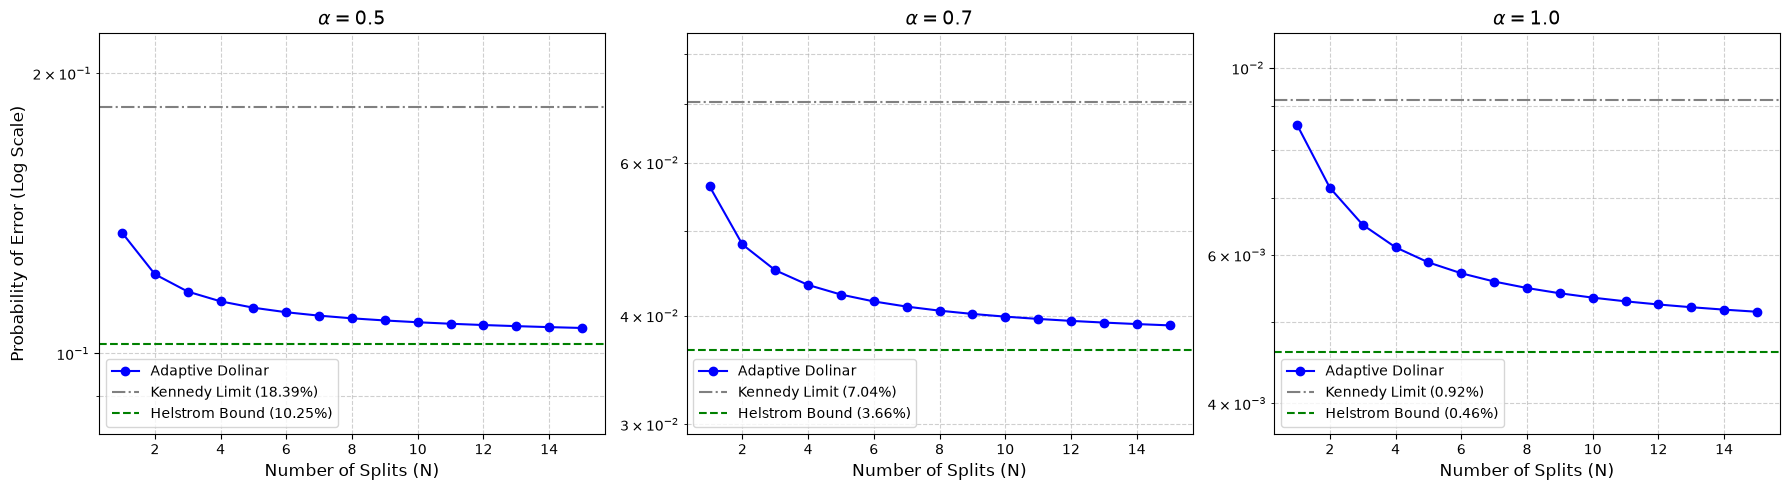

In [67]:
alpha_list = [0.5, 0.7, 1.0]  # You can change this value to test different alpha values
max_splits = 15
exact_errors_list = []
for alpha in alpha_list:
    # Kennedy error formula: 0.5 * exp(-4*alpha^2)
    kennedy_error = 0.5 * np.exp(-4 * alpha**2)
    # Helstrom bound formula: 0.5 * (1 - sqrt(1 - exp(-4*alpha^2)))
    helstrom_error = 0.5 * (1.0 - np.sqrt(1.0 - np.exp(-4 * alpha**2)))

    print(f"--- Analytical Bounds for alpha = {alpha} ---")
    print(f"Standard Kennedy Error: {kennedy_error * 100:.3f}%")
    print(f"Helstrom Minimum Error: {helstrom_error * 100:.3f}%\n")
    print("N Splits | Exact Error Rate | Status")
    print("-" * 45)

    N_values = list(range(1, max_splits + 1))
    exact_errors = []

    for N in N_values:
        err = exact_bayesian_error(alpha, N)
        exact_errors.append(err)

        # Text formatting for the console
        status = "Beats Kennedy!" if err < kennedy_error else "Tied Kennedy"
        print(f"   {N:2d}    |     {err * 100:.3f}%     | {status}")

    exact_errors_list.append(exact_errors)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, alpha in enumerate(alpha_list):
    exact_errors = exact_errors_list[idx]
    kennedy_error = 0.5 * np.exp(-4 * alpha**2)
    helstrom_error = 0.5 * (1.0 - np.sqrt(1.0 - np.exp(-4 * alpha**2)))
    
    # 2. Grab the correct axis directly from the array (No need for if/elif!)
    ax = axes[idx]
    
    ax.semilogy(N_values, exact_errors, marker='o', color='blue', label='Adaptive Dolinar')

    ax.axhline(kennedy_error, color='gray', linestyle='-.', label=f'Kennedy Limit ({kennedy_error*100:.2f}%)')
    ax.axhline(helstrom_error, color='green', linestyle='--', label=f'Helstrom Bound ({helstrom_error*100:.2f}%)')

    ax.set_title(f"$\\alpha = {alpha}$", fontsize=14)
    ax.set_xlabel("Number of Splits (N)", fontsize=12)
    
    # Only put the Y-label on the first plot to keep it clean
    if idx == 0:
        ax.set_ylabel("Probability of Error (Log Scale)", fontsize=12)

    # 3. Log-safe padding: multiply by 0.8 and 1.2 instead of subtracting
    ax.set_ylim([helstrom_error * 0.8, kennedy_error * 1.2])
    
    ax.grid(True, which="both", linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()